### importing the main lib for this course

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json , os , joblib , pathlib

#### importing the lib for this session

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor 
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

### load the models config and some helper function

In [3]:
config = json.load(open('../configs/regression.json'))
base_path = pathlib.Path.cwd().parent.parent.parent
base_path

PosixPath('/home/aloha-zkaria/Hands-on-AI-Tutorial')

In [4]:
def load_dataset(path):
    """
    Args: path
    return : dataframe of the dataset
    """
    return pd.read_csv(base_path/path)

In [5]:
def detect_target(df):
    """fallback: last column"""
    return df.columns[-1]

#### loads the dataset and begin

In [6]:
df = load_dataset(config["datasets"][1]["path"])
print(f'loading dataset name : {config["datasets"][1]["name"]}')

loading dataset name : Life Expectancy


In [7]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [8]:
df.shape

(2938, 22)

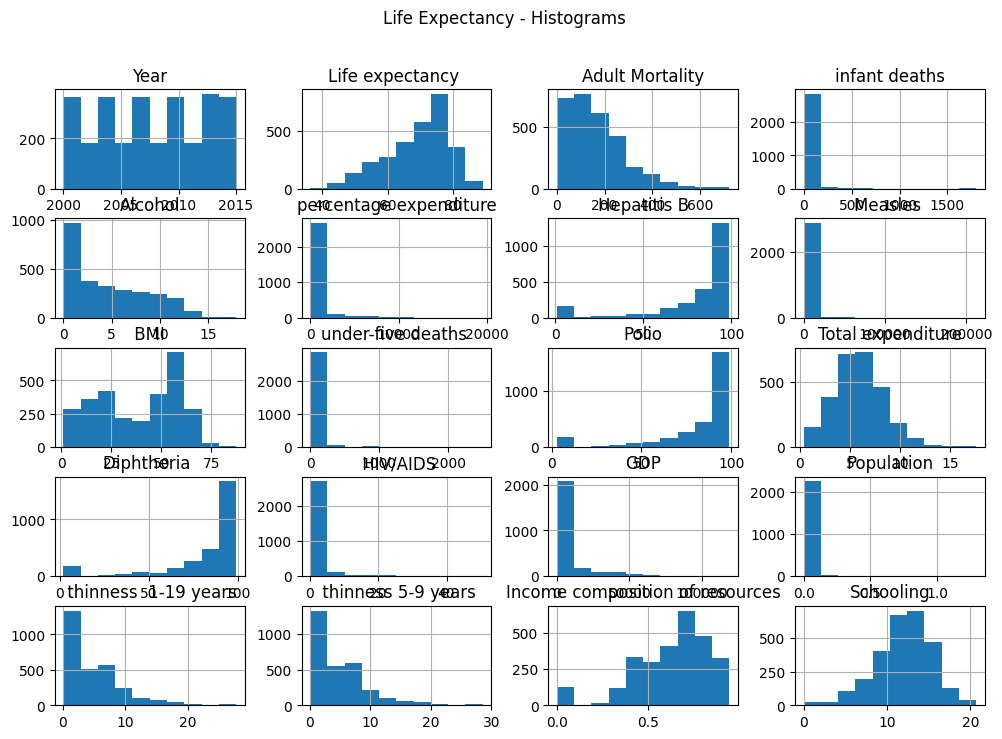

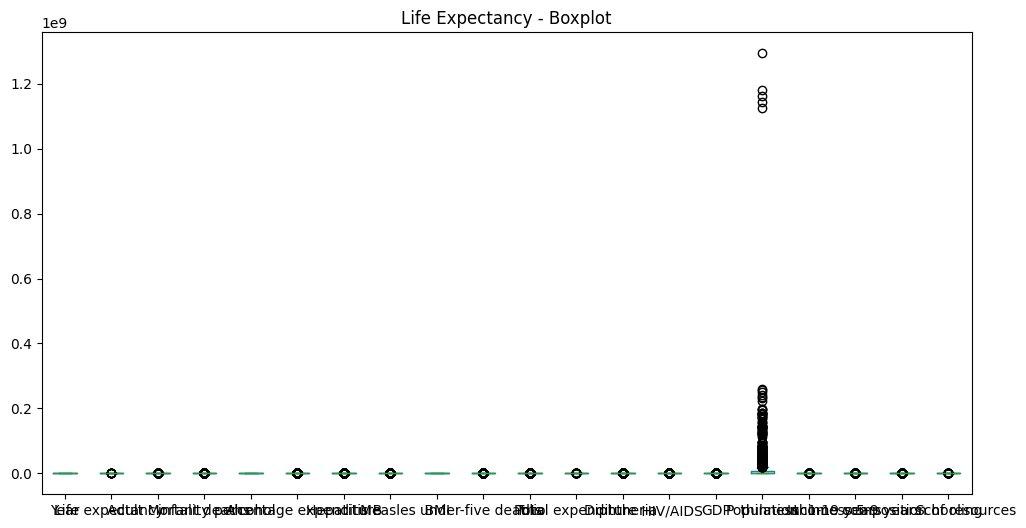

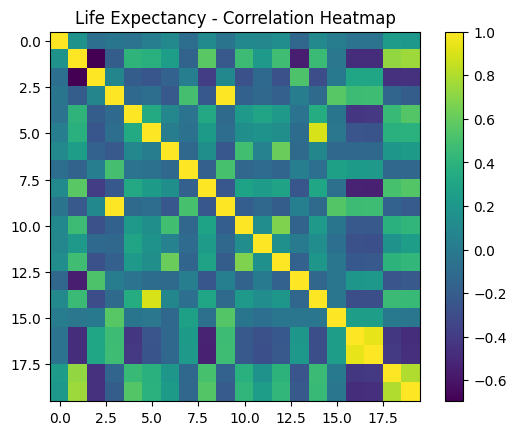

In [9]:
numeric_cols = df.select_dtypes(include="number").columns
name = config["datasets"][1]["name"]
if len(numeric_cols) > 0:
    # Histograms
    df[numeric_cols].hist(figsize=(12, 8))
    plt.suptitle(f"{name} - Histograms")
    plt.show()

    # Boxplot
    df[numeric_cols].plot(kind="box", figsize=(12, 6))
    plt.title(f"{name} - Boxplot")
    plt.show()

    # Correlation heatmap (basic)
    plt.imshow(df.corr(numeric_only=True))
    plt.colorbar()
    plt.title(f"{name} - Correlation Heatmap")
    plt.show()

else:
    print("⚠️ No numeric columns to plot.")

In [10]:
print("\n🔹 DESCRIBE (NUMERIC):")
df.describe()


🔹 DESCRIBE (NUMERIC):


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [11]:
print("\n🔹 MEAN:")
df.mean(numeric_only=True)


🔹 MEAN:


Year                               2.007519e+03
Life expectancy                    6.922493e+01
Adult Mortality                    1.647964e+02
infant deaths                      3.030395e+01
Alcohol                            4.602861e+00
percentage expenditure             7.382513e+02
Hepatitis B                        8.094046e+01
Measles                            2.419592e+03
 BMI                               3.832125e+01
under-five deaths                  4.203574e+01
Polio                              8.255019e+01
Total expenditure                  5.938190e+00
Diphtheria                         8.232408e+01
 HIV/AIDS                          1.742103e+00
GDP                                7.483158e+03
Population                         1.275338e+07
 thinness  1-19 years              4.839704e+00
 thinness 5-9 years                4.870317e+00
Income composition of resources    6.275511e-01
Schooling                          1.199279e+01
dtype: float64

In [12]:
print("\n🔹 MEDIAN:")
df.median(numeric_only=True)


🔹 MEDIAN:


Year                               2.008000e+03
Life expectancy                    7.210000e+01
Adult Mortality                    1.440000e+02
infant deaths                      3.000000e+00
Alcohol                            3.755000e+00
percentage expenditure             6.491291e+01
Hepatitis B                        9.200000e+01
Measles                            1.700000e+01
 BMI                               4.350000e+01
under-five deaths                  4.000000e+00
Polio                              9.300000e+01
Total expenditure                  5.755000e+00
Diphtheria                         9.300000e+01
 HIV/AIDS                          1.000000e-01
GDP                                1.766948e+03
Population                         1.386542e+06
 thinness  1-19 years              3.300000e+00
 thinness 5-9 years                3.300000e+00
Income composition of resources    6.770000e-01
Schooling                          1.230000e+01
dtype: float64

In [13]:
print("\n🔹 STD:")
df.std(numeric_only=True)


🔹 STD:


Year                               4.613841e+00
Life expectancy                    9.523867e+00
Adult Mortality                    1.242921e+02
infant deaths                      1.179265e+02
Alcohol                            4.052413e+00
percentage expenditure             1.987915e+03
Hepatitis B                        2.507002e+01
Measles                            1.146727e+04
 BMI                               2.004403e+01
under-five deaths                  1.604455e+02
Polio                              2.342805e+01
Total expenditure                  2.498320e+00
Diphtheria                         2.371691e+01
 HIV/AIDS                          5.077785e+00
GDP                                1.427017e+04
Population                         6.101210e+07
 thinness  1-19 years              4.420195e+00
 thinness 5-9 years                4.508882e+00
Income composition of resources    2.109036e-01
Schooling                          3.358920e+00
dtype: float64

In [14]:
print("\n🔹 CORRELATION:")
df.corr(numeric_only=True)



🔹 CORRELATION:


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,1.000000,0.170033,-0.079052,-0.037415,-0.052990,0.031400,0.104333,-0.082493,0.108974,-0.042937,0.094158,0.090740,0.134337,-0.139741,0.101620,0.016969,-0.047876,-0.050929,0.243468,0.209400
Life expectancy,0.170033,1.000000,-0.696359,-0.196557,0.404877,0.381864,0.256762,-0.157586,0.567694,-0.222529,0.465556,0.218086,0.479495,-0.556556,0.461455,-0.021538,-0.477183,-0.471584,0.724776,0.751975
Adult Mortality,-0.079052,-0.696359,1.000000,0.078756,-0.195848,-0.242860,-0.162476,0.031176,-0.387017,0.094146,-0.274823,-0.115281,-0.275131,0.523821,-0.296049,-0.013647,0.302904,0.308457,-0.457626,-0.454612
infant deaths,-0.037415,-0.196557,0.078756,1.000000,-0.115638,-0.085612,-0.223566,0.501128,-0.227279,0.996629,-0.170689,-0.128616,-0.175171,0.025231,-0.108427,0.556801,0.465711,0.471350,-0.145139,-0.193720
Alcohol,-0.052990,0.404877,-0.195848,-0.115638,1.000000,0.341285,0.087549,-0.051827,0.330408,-0.112370,0.221734,0.296942,0.222020,-0.048845,0.354712,-0.035252,-0.428795,-0.417414,0.450040,0.547378
percentage expenditure,0.031400,0.381864,-0.242860,-0.085612,0.341285,1.000000,0.016274,-0.056596,0.228700,-0.087852,0.147259,0.174420,0.143624,-0.097857,0.899373,-0.025662,-0.251369,-0.252905,0.381952,0.389687
Hepatitis B,0.104333,0.256762,-0.162476,-0.223566,0.087549,0.016274,1.000000,-0.120529,0.150380,-0.233126,0.486171,0.058280,0.611495,-0.112675,0.083903,-0.123321,-0.120429,-0.124960,0.199549,0.231117
Measles,-0.082493,-0.157586,0.031176,0.501128,-0.051827,-0.056596,-0.120529,1.000000,-0.175977,0.507809,-0.136166,-0.106241,-0.141882,0.030899,-0.076466,0.265966,0.224808,0.221072,-0.129568,-0.137225
BMI,0.108974,0.567694,-0.387017,-0.227279,0.330408,0.228700,0.150380,-0.175977,1.000000,-0.237669,0.284569,0.242503,0.283147,-0.243717,0.301557,-0.072301,-0.532025,-0.538911,0.508774,0.546961
under-five deaths,-0.042937,-0.222529,0.094146,0.996629,-0.112370,-0.087852,-0.233126,0.507809,-0.237669,1.000000,-0.188720,-0.130148,-0.195668,0.038062,-0.112081,0.544423,0.467789,0.472263,-0.163305,-0.209373


In [15]:
print(f"Check null value")
df.isnull().sum()

Check null value


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [16]:
print("Check duplication Value")
df.duplicated().sum()

Check duplication Value


0

In [17]:
target_candidates = ['Life expectancy ', 'Life expectancy', 'life_expectancy',
                     'LifeExpectancy', 'Life Expectancy', 'target', 'Target']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if 'life' in col.lower() and 'expect' in col.lower():
            target_col = col
            print(f"Auto-detected: '{target_col}'")
            break

if target_col is None:
    raise ValueError("Could not identify target")

Found target: 'Life expectancy '


In [18]:
print("droping na value")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

droping na value


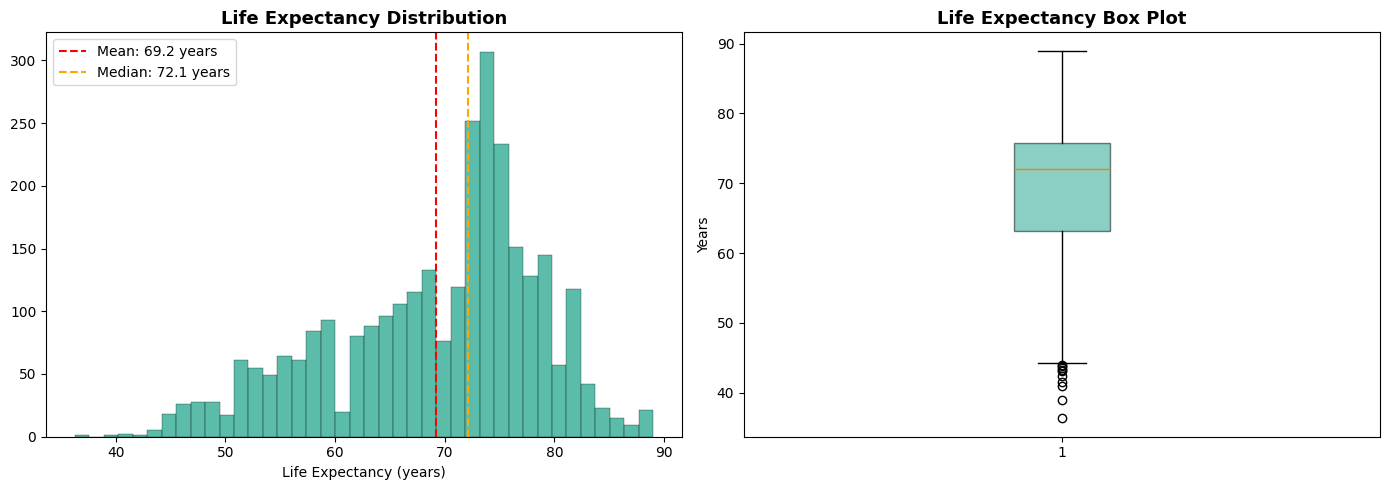

AU context: Australian life expectancy is 83.2 years (2020-22, ABS).
Indigenous life expectancy gap: ~8 years (Closing the Gap target).
SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[target_col], bins=40, color='#16a085', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_title('Life Expectancy Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():.1f} years')
axes[0].axvline(df[target_col].median(), color='orange', linestyle='--', label=f'Median: {df[target_col].median():.1f} years')
axes[0].legend(); axes[0].set_xlabel('Life Expectancy (years)')

axes[1].boxplot(df[target_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#16a085', alpha=0.5))
axes[1].set_title('Life Expectancy Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Years')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Australian life expectancy is 83.2 years (2020-22, ABS).")
print("Indigenous life expectancy gap: ~8 years (Closing the Gap target).")
print("SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.")

### now lets start building the model

In [20]:
df_model = df.copy()

# Drop country name and year (keep Status)
drop_cols = [c for c in df_model.columns if c.lower().strip() in ['country', 'unnamed: 0', 'index', 'id']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)
    print(f"Dropped: {drop_cols}")

Dropped: ['Country']


#### label encoder categories

In [21]:
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

  Encoded 'Status': 2 classes


In [22]:
df_model.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [23]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

#### Split the Dataset

In [24]:
print("Imputing Missing value")
null_total = X.isnull().sum().sum()
if null_total > 0:
    print(f"\nImputing {null_total} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")

Imputing Missing value

Imputing 2513 missing values with median...

Feature matrix: (2928, 20)


In [25]:
x_train , x_test , y_train , y_test = train_test_split(X ,y ,
            test_size=config['splits']['train_test_split']['test_size'],
            random_state=config['splits']['train_test_split']['random_state']
)

#### now creating the models pipeline

In [26]:
MODEL_MAP = {
    "LinearRegression": LinearRegression,
    "RandomForestRegressor": RandomForestRegressor,
    "SVR": SVR,
    "XGBRegressor": XGBRegressor
}

In [27]:
def build_models(config):
    models_config = config["models"]
    models = {}

    for name, model_info in models_config.items():
        algo_name = model_info["algorithm"]
        params = model_info.get("parameters", {})

        if algo_name not in MODEL_MAP:
            raise ValueError(f"Unknown model: {algo_name}")

        model_class = MODEL_MAP[algo_name]
        models[name] = model_class(**params)

    return models

In [28]:
models = build_models(config)

for name, model in models.items():
    print(f"{name} -> {model}")

Linear Regression -> LinearRegression(n_jobs=-1)
Random Forest Regression -> RandomForestRegressor(max_depth=10, n_jobs=-1)
Support Vector Regression -> SVR(gamma=0.1, max_iter=50)
XGBoost Regression -> XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)


#### Start the training of the models

In [29]:
import time
results = {}
for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    t_start = time.time()

    # Train
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    elapsed = time.time() - t_start

    # Store results
    results[model_name] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "time": elapsed,
        "predictions": y_pred
    }

    print(
        f"  -- RMSE: {rmse:.4f} | "
        f"MAE: {mae:.4f} | "
        f"R2: {r2:.4f} | "
        f"Time: {elapsed:.2f}s"
    )


Training: Linear Regression
  -- RMSE: 3.9517 | MAE: 2.9273 | R2: 0.8195 | Time: 0.02s

Training: Random Forest Regression
  -- RMSE: 1.7485 | MAE: 1.1516 | R2: 0.9647 | Time: 0.43s

Training: Support Vector Regression
  -- RMSE: 10.1157 | MAE: 8.8334 | R2: -0.1830 | Time: 0.01s

Training: XGBoost Regression


/home/aloha-zkaria/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  -- RMSE: 1.7977 | MAE: 1.1543 | R2: 0.9626 | Time: 1.21s


#### 6. Model Comparison & Selection¶

In [31]:
summary_rows = []

for model_name, res in results.items():
    summary_rows.append({
        "Model": model_name,
        "RMSE": f"{res['rmse']:.4f}",
        "MAE": f"{res['mae']:.4f}",
        "R2": f"{res['r2']:.4f}",
        "Time": f"{res['time']:.2f}s",
        "sort_val": res["r2"]
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("sort_val", ascending=False)
    .drop(columns=["sort_val"])
)

best_model_name = summary_df.iloc[0]["Model"]

print("MODEL COMPARISON")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print(f"\nBest model: {best_model_name}")

MODEL COMPARISON
                    Model    RMSE    MAE      R2  Time
 Random Forest Regression  1.7485 1.1516  0.9647 0.43s
       XGBoost Regression  1.7977 1.1543  0.9626 1.21s
        Linear Regression  3.9517 2.9273  0.8195 0.02s
Support Vector Regression 10.1157 8.8334 -0.1830 0.01s

Best model: Random Forest Regression


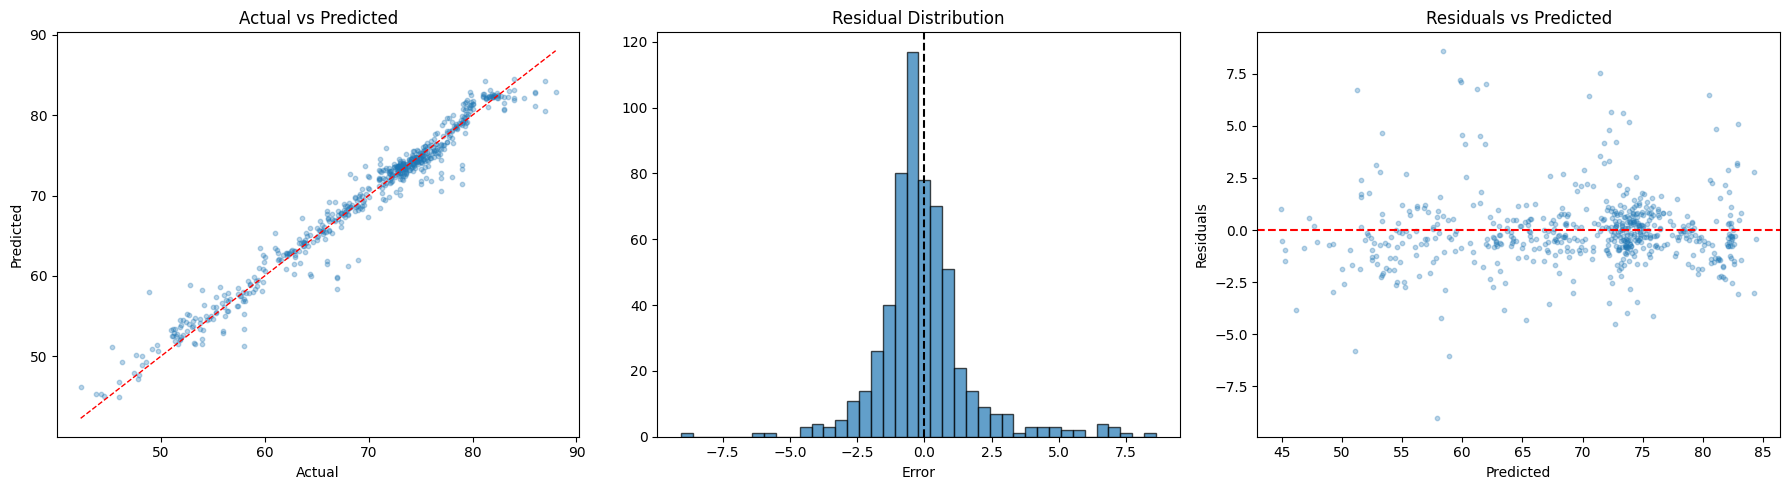

Mean residual: -0.060
Std residual:  1.747
MAE:           1.152


In [33]:
best_preds = results[best_model_name]["predictions"]

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Actual vs Predicted
# =========================
axes[0].scatter(y_test, best_preds, alpha=0.3, s=10)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# =========================
# 2. Residual Distribution
# =========================
axes[1].hist(residuals, bins=40, alpha=0.7, edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error")

# =========================
# 3. Residuals vs Predicted
# =========================
axes[2].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================
# Metrics from residuals
# =========================
print(f"Mean residual: {np.mean(residuals):.3f}")
print(f"Std residual:  {np.std(residuals):.3f}")
print(f"MAE:           {np.mean(np.abs(residuals)):.3f}")

In [35]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE (CLOUD-AGNOSTIC)
============================================================

1. DATA PIPELINE
   Sources:
     - WHO Global Health Observatory
     - World Bank Open Data
     - UNICEF Data
     - United Nations datasets

   Ingestion Layer:
     - API ingestion / batch ETL jobs
     - Streaming optional (Kafka / RabbitMQ / PubSub)

   Storage:
     - Data Lake (S3 / GCS / Azure Blob / On-prem HDFS)
     - Bronze / Silver / Gold layered architecture

   Feature Store:
     - Centralized feature repository (Feast / custom DB)
     - Versioned health, economic, education indicators

   Schedule:
     - Periodic (annual / quarterly based on source updates)

------------------------------------------------------------

2. MODEL SERVING
   Framework:
     - MLflow / custom model registry / cloud-native registry

   Deployment Options:
     - REST API (FastAPI / Flask)
     - Batch inference jobs (scheduled scoring)
     - Kubernetes deployment (optional autoscaling)

   Output:
     - Country-level predictions (life expectancy, risk gaps)
     - Feature importance / drivers analysis
     - Scenario simulation outputs

   Interface:
     - Dashboard (Power BI / Tableau / Superset / custom web app)

------------------------------------------------------------

3. INTEGRATION POINTS
   Government & Research Bodies:
     - Health ministries (policy planning & allocation)
     - WHO & global health organizations
     - National statistics agencies
     - Development banks & NGOs

   Use Cases:
     - Resource allocation optimization
     - Health inequality monitoring
     - Development indicator correlation analysis
     - Early warning for health risks

------------------------------------------------------------

4. GOVERNANCE
   Data Quality:
     - Validation against official statistical benchmarks
     - Missing data handling & anomaly detection

   Bias & Fairness:
     - Monitor under/over-estimation across regions
     - Detect bias in conflict / low-reporting regions

   Transparency:
     - Documented methodology & reproducible pipelines
     - Versioned datasets and models

   Ethics:
     - Respect regional data sovereignty principles
     - Avoid misuse in discriminatory policy decisions

------------------------------------------------------------

5. MONITORING & RETRAINING
   Data Drift:
     - Monitor feature distribution shifts (PSI / KL divergence)

   Performance Tracking:
     - MAE / RMSE against updated ground truth (lagged official stats)

   Retraining Strategy:
     - Scheduled retraining (annual or semi-annual)
     - Event-triggered retraining (pandemics, climate shocks)

   Observability:
     - Logging, metrics dashboards, alerting system

============================================================
""")


PRODUCTION INTEGRATION ARCHITECTURE (CLOUD-AGNOSTIC)

1. DATA PIPELINE
   Sources:
     - WHO Global Health Observatory
     - World Bank Open Data
     - UNICEF Data
     - United Nations datasets

   Ingestion Layer:
     - API ingestion / batch ETL jobs
     - Streaming optional (Kafka / RabbitMQ / PubSub)

   Storage:
     - Data Lake (S3 / GCS / Azure Blob / On-prem HDFS)
     - Bronze / Silver / Gold layered architecture

   Feature Store:
     - Centralized feature repository (Feast / custom DB)
     - Versioned health, economic, education indicators

   Schedule:
     - Periodic (annual / quarterly based on source updates)

------------------------------------------------------------

2. MODEL SERVING
   Framework:
     - MLflow / custom model registry / cloud-native registry

   Deployment Options:
     - REST API (FastAPI / Flask)
     - Batch inference jobs (scheduled scoring)
     - Kubernetes deployment (optional autoscaling)

   Output:
     - Country-level predictions (